In [ ]:
import pandas as P
import seaborn as S
import numpy as N
import matplotlib.pyplot as MAT
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
Data_1 = P.read_csv('/content/diabetes_dataset.csv')

In [ ]:
Data_1

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


In [ ]:
Data_1.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


In [ ]:
Data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

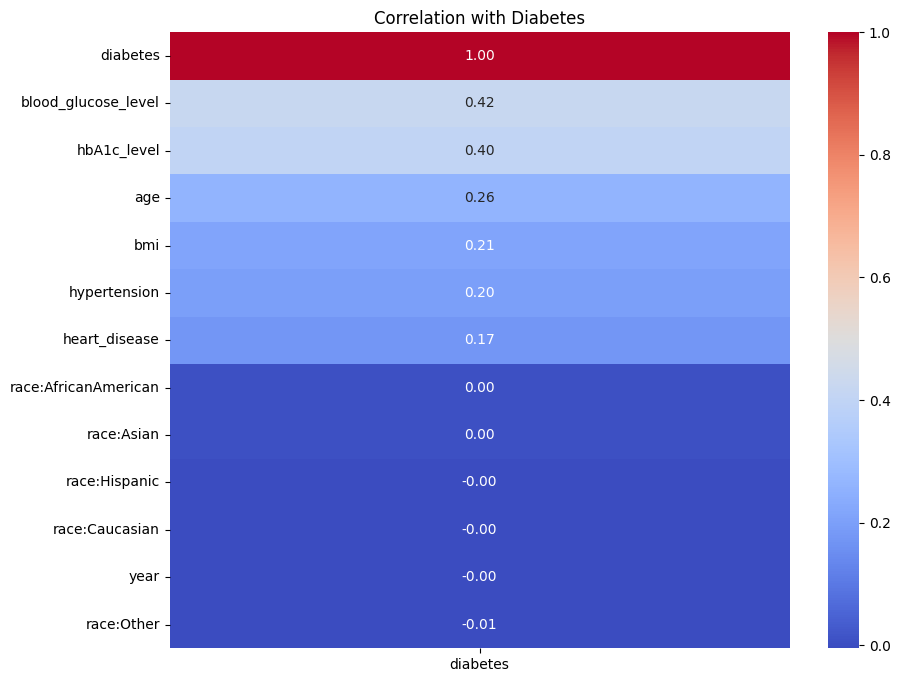

In [ ]:
correlation_matrix = Data_1.corr(numeric_only=True)
MAT.figure(figsize=(10, 8))
S.heatmap(correlation_matrix[['diabetes']].sort_values(by='diabetes', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
MAT.title('Correlation with Diabetes')
MAT.show()

In [ ]:
Data_1

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


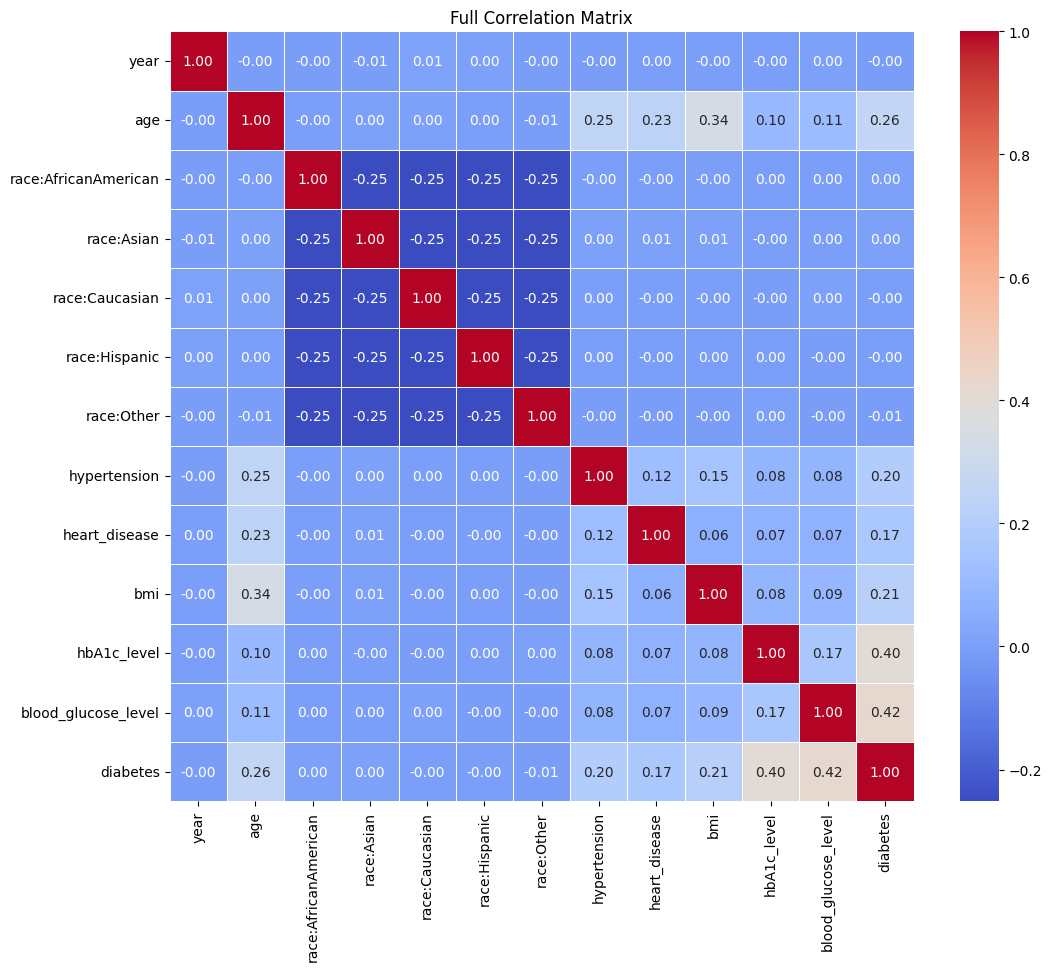

In [ ]:
correlation_matrix_full = Data_1.corr(numeric_only=True)
MAT.figure(figsize=(12, 10))
S.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
MAT.title('Full Correlation Matrix')
MAT.show()

In [ ]:
columns_to_drop = ['race:Other', 'year', 'race:Caucasian', 'race:Hispanic', 'race:Asian', 'race:AfricanAmerican']
Data_1 = Data_1.drop(columns=columns_to_drop, errors='ignore')
Data_1.head()

,gender,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,Alabama,0,0,never,27.32,5.0,100,0
1,Female,29.0,Alabama,0,0,never,19.95,5.0,90,0
2,Male,18.0,Alabama,0,0,never,23.76,4.8,160,0
3,Male,41.0,Alabama,0,0,never,27.32,4.0,159,0
4,Female,52.0,Alabama,0,0,never,23.75,6.5,90,0


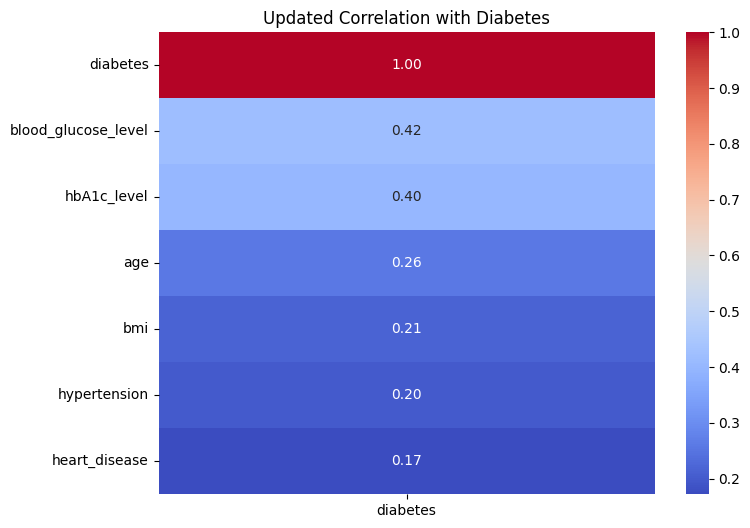

In [ ]:
new_corr = Data_1.corr(numeric_only=True)[['diabetes']].sort_values(by='diabetes', ascending=False)
MAT.figure(figsize=(8, 6))
S.heatmap(new_corr, annot=True, cmap='coolwarm', fmt='.2f')
MAT.title('Updated Correlation with Diabetes')
MAT.show()

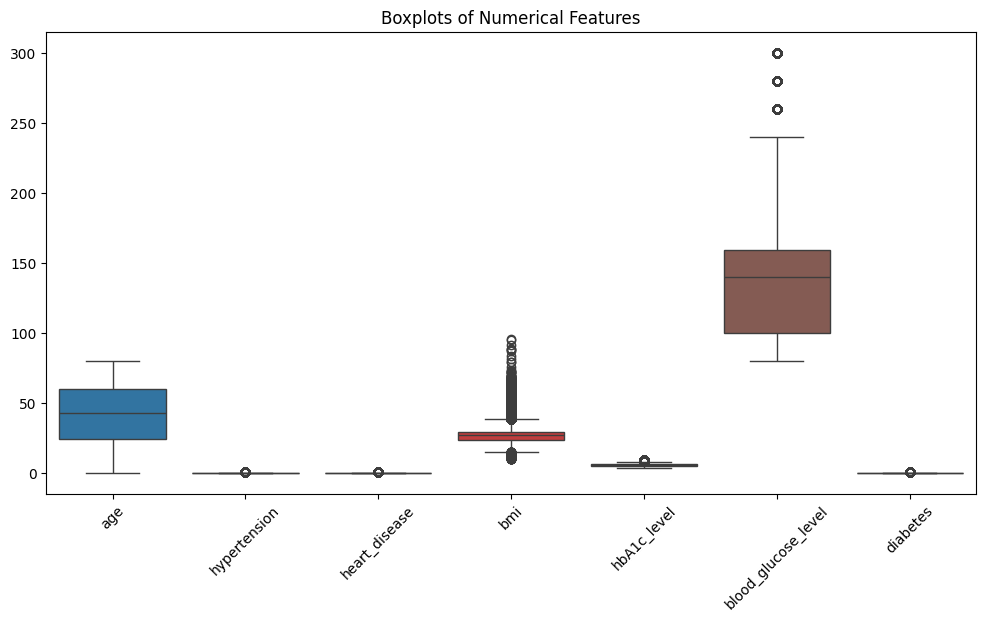

In [ ]:
numerical_cols = Data_1.select_dtypes(include=[N.number]).columns
MAT.figure(figsize=(12, 6))
S.boxplot(data=Data_1[numerical_cols])
MAT.xticks(rotation=45)
MAT.title("Boxplots of Numerical Features")
MAT.show()

In [ ]:
outlier_indices = set()
numerical_cols_to_check = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

for col in numerical_cols_to_check:
    Q1 = Data_1[col].quantile(0.25)
    Q3 = Data_1[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    indices = Data_1[(Data_1[col] < lower_bound) | (Data_1[col] > upper_bound)].index
    outlier_indices.update(indices)

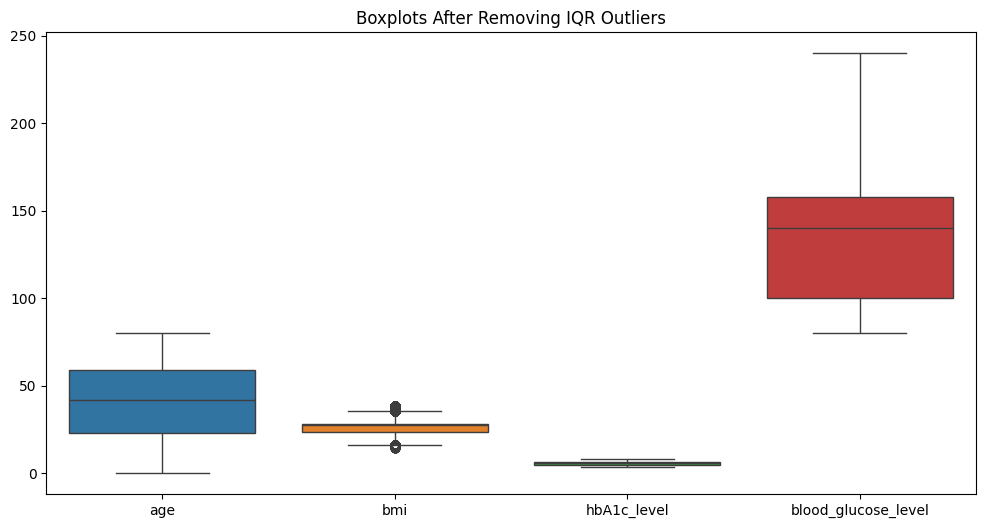

In [ ]:
Data_1_cleaned = Data_1.drop(index=outlier_indices)

cols_to_plot = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
MAT.figure(figsize=(12, 6))
S.boxplot(data=Data_1_cleaned[cols_to_plot])
MAT.title("Boxplots After Removing IQR Outliers")
MAT.show()

In [ ]:
Data

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


In [ ]:
Data_1_cleaned

,gender,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,32.0,Alabama,0,0,never,27.32,5.0,100,0
1,Female,29.0,Alabama,0,0,never,19.95,5.0,90,0
2,Male,18.0,Alabama,0,0,never,23.76,4.8,160,0
3,Male,41.0,Alabama,0,0,never,27.32,4.0,159,0
4,Female,52.0,Alabama,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...
99995,Female,33.0,Wyoming,0,0,never,21.21,6.5,90,0
99996,Female,80.0,Wyoming,0,0,No Info,36.66,5.7,100,0
99997,Male,46.0,Wyoming,0,0,ever,36.12,6.2,158,0
99998,Female,51.0,Wyoming,0,0,not current,29.29,6.0,155,0


In [ ]:
# Re-create Data_1_cleaned to ensure a fresh state for encoding
Data_1_cleaned = Data_1.drop(index=outlier_indices).copy()

# 1. Label Encoding for Gender (Binary/Low cardinality)
le = LabelEncoder()
Data_1_cleaned['gender'] = le.fit_transform(Data_1_cleaned['gender'])

# 2. One-Hot Encoding for smoking_history and location
# This creates new columns and drops the original categorical ones
Data_1_cleaned = P.get_dummies(Data_1_cleaned, columns=['smoking_history', 'location'], dtype=int)

# Display the first few rows and column list to verify
print(f"New shape: {Data_1_cleaned.shape}")
Data_1_cleaned.head()

New shape: (90387, 69)


,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,...,location_Texas,location_United States,location_Utah,location_Vermont,location_Virgin Islands,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming
0,0,32.0,0,0,27.32,5.0,100,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,29.0,0,0,19.95,5.0,90,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,18.0,0,0,23.76,4.8,160,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,41.0,0,0,27.32,4.0,159,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,52.0,0,0,23.75,6.5,90,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# List of columns to scale
cols_to_scale = ['age', 'bmi', 'blood_glucose_level', 'hbA1c_level']

# Apply scaling to the specified columns
Data_1_cleaned[cols_to_scale] = scaler.fit_transform(Data_1_cleaned[cols_to_scale])

# Display the first few rows to verify scaling
Data_1_cleaned[cols_to_scale].head()

,age,bmi,blood_glucose_level,hbA1c_level
0,0.399399,0.530055,0.12500,0.319149
1,0.361862,0.220261,0.06250,0.319149
2,0.224224,0.380412,0.50000,0.276596
3,0.512012,0.530055,0.49375,0.106383
4,0.649650,0.379992,0.06250,0.638298


In [ ]:
Data_1_cleaned

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,...,location_Texas,location_United States,location_Utah,location_Vermont,location_Virgin Islands,location_Virginia,location_Washington,location_West Virginia,location_Wisconsin,location_Wyoming
0,0,0.399399,0,0,0.530055,0.319149,0.12500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.361862,0,0,0.220261,0.319149,0.06250,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0.224224,0,0,0.380412,0.276596,0.50000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0.512012,0,0,0.530055,0.106383,0.49375,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.649650,0,0,0.379992,0.638298,0.06250,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,0.411912,0,0,0.273224,0.638298,0.06250,0,0,0,...,0,0,0,0,0,0,0,0,0,1
99996,0,1.000000,0,0,0.922657,0.468085,0.12500,0,1,0,...,0,0,0,0,0,0,0,0,0,1
99997,1,0.574575,0,0,0.899958,0.574468,0.48750,0,0,0,...,0,0,0,0,0,0,0,0,0,1
99998,0,0.637137,0,0,0.612863,0.531915,0.46875,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
Data_1_cleaned.duplicated().sum()

np.int64(116)

1) LR

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Define features (X) and target (y) from the cleaned and scaled dataframe
X = Data_1_cleaned.drop('diabetes', axis=1)
y = Data_1_cleaned['diabetes']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, max_iter=10000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.9639

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17179
           1       0.80      0.37      0.50       899

    accuracy                           0.96     18078
   macro avg       0.88      0.68      0.74     18078
weighted avg       0.96      0.96      0.96     18078



2. SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the SVM classifier
# Note: With ~90k rows, SVM can be slow. Using a linear kernel or limiting max_iter can help if it hangs.
svm_model = SVC(kernel='linear', random_state=42)

# Training the model
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print(f"SVM Accuracy Score: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy Score: 0.9618

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17179
           1       0.98      0.24      0.38       899

    accuracy                           0.96     18078
   macro avg       0.97      0.62      0.68     18078
weighted avg       0.96      0.96      0.95     18078



3. nayve bayse

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Naive Bayes classifier
nb_model = GaussianNB()

# Training the model
nb_model.fit(X_train, y_train)

# Predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print(f"Naive Bayes Accuracy Score: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy Score: 0.8651

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.93     17179
           1       0.19      0.54      0.29       899

    accuracy                           0.87     18078
   macro avg       0.58      0.71      0.61     18078
weighted avg       0.93      0.87      0.89     18078



4. DT

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Training the model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print(f"Decision Tree Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy Score: 0.9587

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     17179
           1       0.59      0.58      0.58       899

    accuracy                           0.96     18078
   macro avg       0.78      0.78      0.78     18078
weighted avg       0.96      0.96      0.96     18078



5. KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize KNN (default n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluation
print(f"KNN Accuracy Score: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy Score: 0.9499

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     17179
           1       0.48      0.07      0.12       899

    accuracy                           0.95     18078
   macro avg       0.72      0.53      0.55     18078
weighted avg       0.93      0.95      0.93     18078



6. RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print(f"Random Forest Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy Score: 0.9743

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17179
           1       0.99      0.49      0.66       899

    accuracy                           0.97     18078
   macro avg       0.98      0.75      0.82     18078
weighted avg       0.97      0.97      0.97     18078



7. XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the XGBoost classifier
# scale_pos_weight can be used if we want to further address class imbalance
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Training the model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
print(f"XGBoost Accuracy Score: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy Score: 0.9748

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17179
           1       0.98      0.50      0.67       899

    accuracy                           0.97     18078
   macro avg       0.98      0.75      0.83     18078
weighted avg       0.97      0.97      0.97     18078



8.bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Bagging Classifier
# By default, it uses DecisionTreeClassifier as the base estimator
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)

# Training the model
bagging_model.fit(X_train, y_train)

# Predictions
y_pred_bagging = bagging_model.predict(X_test)

# Evaluation
print(f"Bagging Classifier Accuracy Score: {accuracy_score(y_test, y_pred_bagging):.4f}")
print("\nBagging Classifier Classification Report:")
print(classification_report(y_test, y_pred_bagging))

Bagging Classifier Accuracy Score: 0.9733

Bagging Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17179
           1       0.92      0.51      0.65       899

    accuracy                           0.97     18078
   macro avg       0.95      0.75      0.82     18078
weighted avg       0.97      0.97      0.97     18078



9. Gradient boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
print(f"Gradient Boosting Accuracy Score: {accuracy_score(y_test, y_pred_gb):.4f}")
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy Score: 0.9745

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17179
           1       0.97      0.50      0.66       899

    accuracy                           0.97     18078
   macro avg       0.97      0.75      0.82     18078
weighted avg       0.97      0.97      0.97     18078

